# Duplicates videos

In [56]:
import pandas as pd
df = pd.read_csv('/Users/van/code/social-media-optimizer/social-media-optimizer/data/raw/Post level data 2023 - 2026 - Funnel data.csv')

In [57]:
df.columns.to_list()

['NZR - Paid campaign name (Short)',
 'NZR - Year',
 'NZR - Page Name',
 'NZR - Platform Code',
 'NZR - Media Type',
 'NZR - Content Hierarchy L0',
 'NZR - Content Hierarchy L1',
 'NZR - Content Hierarchy L2',
 'NZR - Post URL',
 'NZR - Post Content (Low Case)',
 'NZR - Cost (NZD)',
 'NZR - Views',
 'NZR - Hours',
 'NZR - Engagement']

In [58]:
df.shape

(76673, 14)

In [92]:
from pandas.api.types import is_numeric_dtype

platforms=['IG','FB','TT','YT']

df_clean = df[df['NZR - Platform Code'].isin(platforms) & (df['NZR - Media Type'] == 'Short Video')]\
    .drop_duplicates() \
    .rename(columns = {'NZR - Post Content (Low Case)':'caption long', 'id':'post_id','NZR - Platform Code': 'platform_v1'})

df_clean['platform_v2'] = df_clean['platform_v1'].replace({
    'IG': 'Meta',
    'FB': 'Meta'
})

df_clean['caption'] = df_clean['caption long'].str[:200]

df_small = df_clean[['NZR - Post URL','caption','platform_v2']].drop_duplicates()

df_final = (
    df_small.groupby(['caption','platform_v2'], as_index=False, sort=False, dropna=False)
      .agg('first')
)

df_small['platform_v2'].value_counts() , (df_small['platform_v2'].value_counts() - df_final['platform_v2'].value_counts())

# #df_final.sample(5)
# #df_small.to_csv('small_1.csv', index=False)

(platform_v2
 Meta    9453
 TT      2138
 YT      1552
 Name: count, dtype: int64,
 platform_v2
 Meta    2728
 TT        84
 YT       615
 Name: count, dtype: int64)

In [85]:
df_clean['length'] = df_clean['caption long'].str.len()

df_meta = df_clean[df_clean['platform_v2'].isin(['Meta'])]

df_meta['length'].quantile(0.90)

df_clean['NZR - views'].quartile(0.90),df_clean['NZR - views'].quartile(0.50)

227.0

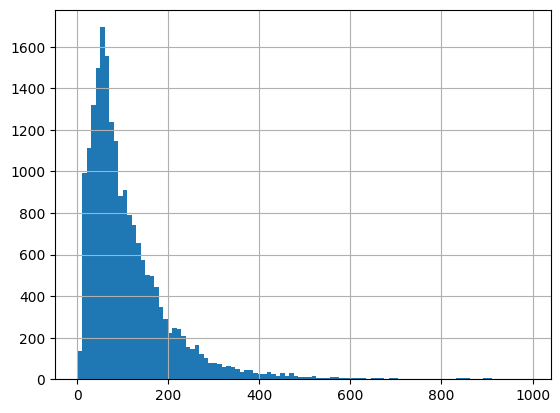

In [87]:
df_meta[df_meta['length']<1000]['length'].hist(bins=100);

In [61]:
from pandas.api.types import is_numeric_dtype

result = (
    df_small.groupby(['caption','NZR - Platform Code'], as_index=False, sort=False, dropna=False)
      .agg({column: 'sum' if is_numeric_dtype(df_small[column]) else 'first'
            for column in df.columns
            if column not in ['caption', 'counts']
           })
)

result['count'] = (
    df_small.groupby(['caption','NZR - Platform Code'], sort=False, dropna=False)
      .size()
      .to_numpy()
)

result.to_csv('small_3.csv', index=False)

In [15]:
df_dict = df_reduced.to_dict(orient='records')

In [55]:
df_processed = pd.read_csv("/Users/van/Desktop/processed.csv")
df_reduced = df_processed[['id','NZR - Post Content (Low Case)', 'description']].dropna().rename(columns = {'NZR - Post Content (Low Case)':'caption', 'id':'post_id'})

In [16]:
from pydantic import BaseModel, Field
from typing import Literal

ContentTheme = Literal[
    "training",
    "match_action",
    "haka",
    "preparation",
    "player_story",
    "rugby_skills",
    "rivalry",
    "celebration",
    "milestone",
    "team_selection",
    "other",
    "unclear",
]

FormatAccess = Literal[
    "highlight",
    "interview",
    "montage",
    "candid_clip",
    "announcement",
    "behind_the_scenes",
    "player_pov",
    "broadcast",
    "archival",
    "other",
    "unclear",
]

Tone = Literal[
    "humour",
    "excitement",
    "pride",
    "tension",
    "nostalgia",
    "inspiration",
    "warmth",
    "serious",
    "other",
    "unclear",
]

Context = Literal[
    "training_week",
    "pre_match",
    "match_day",
    "post_match",
    "off_season",
    "pitch",
    "gym",
    "changing_room",
    "stadium",
    "travel",
    "community_event",
    "other",
    "unclear",
]


class Entity(BaseModel):
    entity_type: Literal[
        "player",
        "coach",
        "team",
        "opponent",
        "fan",
        "alumni",
        "brand",
        "product",
        "other",
    ]
    entity_name: str | None


class PostClassification(BaseModel):
    post_id: str
    content_themes: list[ContentTheme] = Field(max_length=3)
    format_access: list[FormatAccess] = Field(max_length=2)
    people_entities: list[Entity]
    tones: list[Tone] = Field(bmax_length=2)
    contexts: list[Context] = Field(max_length=3)
    suggested_new_themes: list[str] = Field(max_length=3)
    classification_confidence: float = Field(ge=0, le=1)

In [20]:
df_reduced.shape
df_dict[50]

{'post_id': 'tt_7565291738936528148',
 'caption': 'our people in chicago 🖤 #chicago #rugby #allblacks ',
 'description': 'The video shows members of the New Zealand All Blacks rugby team interacting with fans at a "Takeover" fan event in Chicago. Throughout the video, players are seen walking in the city, signing autographs, posing for photos with fans of all ages in front of event backdrops, and observing fans enjoying activities and taking pictures with the Gallagher Cup trophy.'}

In [ ]:
import json
from ollama import chat

post = df_dict[50]
response = chat(
    model="qwen3:8b",  # Example; use a model available locally
    messages=[
        {
            "role": "system",
            "content": (
                "Classify All Blacks short-form social content. "
                "Use only observable evidence. Do not infer performance. "
                "Select only materially present labels."
            ),
        },
        {
            "role": "user",
            "content": json.dumps(post, ensure_ascii=False),
        },
    ],
    format=PostClassification.model_json_schema(),
    options={"temperature": 0},
)

classification = PostClassification.model_validate_json(
    response.message.content
)

print(classification.model_dump())